In [1]:
import mat73
import numpy as np
from matplotlib import pyplot as plt
from scipy.constants import h, c as c0,e

from qnmsc.surmof_cavity import ag_surmof_cavity_smat
from qnmsc.track_qnms import track_qnms
from qnmsc.plot_trajectories import load_data, select_modes
from qnmsc.plot_splitting import plot_splitting
from qnmsc.mpl_config import um, inv_um, mm, config

config()
k0_to_eV = 1e6*h*c0/e/(2*np.pi)

%autoreload

In [2]:
data_dict = mat73.loadmat("assets/in/data_figure6/Data_SMA.mat")
kn = data_dict['kn']
thickness_surmof = np.array([T[0][1] for T in kn['T']])
Nt = len(thickness_surmof)
poles = np.sort(kn['poles'][0][0])[-3:] * k0_to_eV

In [3]:
q_rse   = np.zeros((Nt, 4), dtype=complex)
gcoeff  = np.zeros((Nt, 3), dtype=complex)
kcshift = np.zeros((Nt, 1), dtype=complex)
kc      = np.zeros((Nt, 1), dtype=complex)

for i in range(Nt):
    q_rse[i,:] = np.sort(kn['knNew'][i][0])

    gcoeff[i,:] = kn['coupl_coeffs'][i][0][::-1]
    kcshift[i] = kn['knShift'][i][0]
    kc[i] = kn['knVal'][i][0][0]

q_rse   *= k0_to_eV
gcoeff  *= k0_to_eV
kcshift *= k0_to_eV
kc      *= k0_to_eV


In [25]:
on_resonance_idx = np.argmin(np.abs(kc.real[:,None]-poles.real[None,:]), axis=0).ravel()

In [26]:
X_rse = thickness_surmof*1e6

In [27]:
hbar_omega = np.linspace(1, 2.5, 401)
inv_d = np.linspace(0.6, 16, 1021)
E, T = np.meshgrid(hbar_omega, 1/inv_d)

smat = ag_surmof_cavity_smat( 
  E, T
)

from matplotlib.colors import ListedColormap
a = 0.7
my_cmap = plt.cm.viridis(np.arange(plt.cm.viridis.N))
my_cmap[:,0:3] *= a 
my_cmap = ListedColormap(my_cmap)

QNMs at rabi: [1.4565377 -0.0555689j  1.7987035 -0.01398423j 1.84747228-0.01379213j
 2.09787132-0.09162223j]


/mnt/data/jd/code/misc/agsurmof/qnmsc/inverse_eigenproblem.py:50: RuntimeWarning: invalid value encountered in divide
  fac = -1/(oms-evs)
/mnt/data/jd/code/misc/agsurmof/qnmsc/plot_splitting.py:152: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=5, labelcolor=c_font, loc=legend_loc)
/mnt/data/jd/code/misc/agsurmof/qnmsc/plot_splitting.py:182: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=5, title="Material Resonances", loc="lower right", frameon=True)


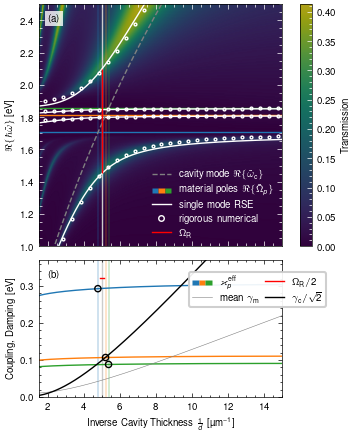

In [30]:
from qnmsc.mpl_config import MulticolorPatch, MulticolorPatchHandler

inv_d = True
Param = 1/X_rse if inv_d else X_rse
on_resonance_param = Param[on_resonance_idx]

domain = [0.7-0.7j, 5.0+0.05j]

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(90*mm, 110*mm), height_ratios=[3,1.7], constrained_layout=True)

plt.sca(axs[0])
plt.pcolormesh(1/T if inv_d else T, E, np.abs(smat['in', 'out'])**2, zorder=-2, rasterized=True, shading='gouraud', cmap=my_cmap)
cbar = plt.colorbar(label="Transmission")

plt.tick_params(which='both', color="white")
cbar.ax.tick_params(which='both', color="white")

for which, length, width in zip(['major', 'minor'], [3.5, 2], [0.5,0.5]):
  plt.tick_params(which=which, length=length, width=width)
  cbar.ax.tick_params(which=which, length=length, width=width)

fig, axs, om_os, Cs, param = plot_splitting(
    1,3,1,1,domain, inv_d=inv_d, return_fit=True, plot_dots=False, n_interp=200, 
    axs=axs, ylim=(min(hbar_omega), max(hbar_omega)),
    plot_cavity_mode=False, c_higher=[0,0,0,0], c_fundamental="white", 
    plot_extracted_coupling=False, scatter_numerical=True)

for ax in axs:
  for i, on_res_p in enumerate(on_resonance_param):
    ax.axvline(on_res_p, ls="-", color=f"C{i}", lw=0.3, zorder=-1)

plt.sca(axs[1])
#plt.yscale('log')
#plt.ylim(0.005, 0.4)
kappa = np.sqrt(np.abs(gcoeff*poles))
for i, (on_res_p, on_res_i) in enumerate(zip(on_resonance_param, on_resonance_idx)):
  plt.scatter([on_res_p], [kappa[on_res_i, i]], color=f"C{i}", facecolor='none', edgecolor="k", zorder=3, s=20)

plt.ylim(0, 0.37)

plt.plot(Param, kappa)
# plt.plot(Param, np.sqrt(np.real(-gcoeff*poles)), color="k") # -> mostly real, but not fully -> dissipative coupling
#for i, gamma in enumerate(-poles.imag.T):
  #plt.axhline(gamma, ls="--", color=f"C{i}")
  #plt.plot(Param, gamma, color=f"C{i}", ls="--")


plt.plot(Param, np.mean(-q_rse.imag, axis=-1), lw=0.4, color="gray", label="mean $\gamma_\mathrm{m}$")
plt.plot([],[], color="r", label=r"$\Omega_\mathrm{R}/2$")
#plt.plot(Param, -kc.imag, "gray", ls="--", label=r"$\gamma_\mathrm{c}$")
plt.plot(Param, -kc.imag/np.sqrt(2), ls="-", color="k", label=r"$\gamma_\mathrm{c}/\sqrt{2}$")

#plt.gca().get_legend().remove()
plt.ylabel(r"Coupling, Damping [eV]")

# ------ get the legend-entries that are already attached to the axis
h, l = axs[1].get_legend_handles_labels()

# ------ append the multicolor legend patches
h.insert(0, MulticolorPatch(['C0', 'C1', 'C2']))
l.insert(0, r"$\varkappa^\mathrm{eff}_p$")

# h.append(MulticolorPatch(['C0', 'C1', 'C2'], width_scaling=0.7, height_scaling=0.7**2))
# l.append(r"$\gamma_p$")

# ---- Lock the layout here ----
# Force layout to be computed
fig.canvas.draw()
# Disable constrained layout (positions are now frozen)
fig.set_constrained_layout(False)

legend = plt.legend(h, l, loc="upper right", frameon=True, 
      handler_map={MulticolorPatch: MulticolorPatchHandler()}, ncol=2, 
      bbox_to_anchor=(1.2, 0.95), columnspacing=0.7)
legend.get_frame().set_alpha(0.93) 
legend.get_frame().set_linewidth(1.5)

if inv_d:
  plt.xlim(1.5, 15)
else:
  plt.xlim(0.05, 0.5)

plt.sca(axs[0])
plt.plot(Param, q_rse.real, color="white")
#plt.plot(Param, kcshift.real)
plt.plot(Param, kc.real, "gray", ls="--")


plt.plot([], [], color="gray", ls="--", label=r"cavity mode $\Re\{\tilde{\omega}_\mathrm{c}\}$")
plt.plot([], [], color="white", label="single mode RSE")
plt.plot([], [], label="rigorous numerical", mec="white", marker="o", mfc="none", ls="none", ms=4)
plt.plot([], [], color="r", label="$\Omega_\mathrm{R}$")

# ------ get the legend-entries that are already attached to the axis
h, l = axs[0].get_legend_handles_labels()

# ------ append the multicolor legend patches
h.insert(1, MulticolorPatch(['C0', 'C1', 'C2']))
l.insert(1, r"material poles $\Re\{\tilde{\Omega}_p\}$")

plt.legend(h, l, handler_map={MulticolorPatch: MulticolorPatchHandler()}, labelcolor="white", loc="lower right")

for j, ax in enumerate(axs):
  letter = chr(ord("a")+j)
  ax.annotate(
        f" ({letter})",
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+1, -1), textcoords='offset fontsize',
        fontsize='medium', verticalalignment='top', fontfamily='serif',
        bbox=dict(facecolor=(1,1,1,0.8), edgecolor='none', pad=2.0))
    
plt.savefig("out/SMA_RSE.pdf", bbox_inches="tight")